# Random Forest: Xếp hạng khách hàng cho telesales

Pipeline đầy đủ: tiền xử lý → baseline → Random Forest → chọn tham số bằng OOB/CV (không đụng vào tập test) → đánh giá → xuất danh sách gọi.

Toàn bộ dùng phiên bản dữ liệu **không có `duration`** — cột này bị loại ngay ở bước đọc dữ liệu (xem lý do và bằng chứng bằng số ở `leakage_demo.ipynb`).

In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV,
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42

REPORTS_DIR = "reports"
OUTPUTS_DIR = "outputs"
MODELS_DIR = "models"
for d in (REPORTS_DIR, OUTPUTS_DIR, MODELS_DIR):
    os.makedirs(d, exist_ok=True)


## 1. Đọc dữ liệu (bỏ `duration` ngay khi đọc)

In [ ]:

df = pd.read_csv("data/bank/bank-full.csv", sep=";")
df = df.drop(columns=["duration"])   # BẮT BUỘC bỏ để tránh rò rỉ dữ liệu — bỏ ngay tại đây

y = (df["y"] == "yes").astype(int)
X = df.drop(columns=["y"])
print(X.shape, "| tỉ lệ yes:", round(y.mean(), 3))


(45211, 15) | tỉ lệ yes: 0.117


## 2. Baseline & train/test split

Chia train/test trước, rồi mới xây các bước tiền xử lý dựa trên train — tránh rò rỉ.

In [3]:
cat_cols = X.select_dtypes(include="object").columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)


## 3. Xử lý `pdays` và giá trị `'unknown'`

**Đây là bộ `bank-full.csv` (bộ "bank" gốc), không phải `bank-additional-full.csv`.** Hai bộ dùng quy ước khác nhau cho "khách chưa từng được liên hệ trước đó":

| Bộ dữ liệu | Sentinel nghĩa là "chưa từng liên hệ" |
|---|---|
| `bank-additional-full.csv` | `pdays == 999` |
| `bank-full.csv` (bộ đang dùng ở đây) | `pdays == -1` |

Bản trước của notebook này lỡ dùng quy ước `999` trong khi dữ liệu thực tế là `bank-full.csv` (quy ước `-1`) → `pdays != 999` đúng với **toàn bộ 45.211 dòng** (vì không dòng nào có `pdays == 999`), nên `was_contacted_before` bị hằng số 1 vô nghĩa, và `replace(999, -1)` không đổi gì cả. Ô kiểm chứng bên dưới xác nhận lại điều này trước khi sửa.

- `-1` nghĩa là "chưa từng liên hệ" — không phải một số ngày âm thật, nên tách thành cờ riêng để model không hiểu nhầm là "âm 1 ngày".
- `'unknown'` ở `job`/`education`/`housing`... để nguyên, coi như một mức riêng của biến phân loại (OneHotEncoder sẽ tự xử lý như bình thường).

In [4]:
# Kiểm chứng quy ước trước khi xử lý (đối chiếu với audit: n(pdays==999)=0, n(pdays==-1)=36954)
print("n(pdays == 999):", int((X_train["pdays"] == 999).sum()))
print("n(pdays == -1):", int((X_train["pdays"] == -1).sum()))


n(pdays == 999): 0
n(pdays == -1): 29584


In [5]:
def add_pdays_flag(frame):
    frame = frame.copy()
    frame["was_contacted_before"] = (frame["pdays"] != -1).astype(int)
    # -1 không phải "âm 1 ngày": thay bằng 0 để không đưa giá trị âm vô nghĩa vào model.
    # Cờ was_contacted_before đã lưu lại thông tin "chưa từng liên hệ" nên không mất thông tin.
    frame["pdays"] = frame["pdays"].replace(-1, 0)
    return frame

X_train = add_pdays_flag(X_train)
X_test = add_pdays_flag(X_test)

print("Tỉ lệ was_contacted_before == 1:", round(X_train["was_contacted_before"].mean(), 3))


Tỉ lệ was_contacted_before == 1: 0.182


## 4. Pipeline tiền xử lý (OneHotEncoder trong ColumnTransformer)

In [6]:
preprocess = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)],
    remainder="passthrough")


## 5. Baseline: Dummy & cây quyết định đơn (so sánh với TT-02)

In [7]:
def eval_model(model, name):
    model.fit(X_train, y_train)
    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"{name:20s} ROC-AUC = {auc:.3f}")
    return auc

dummy = Pipeline([("prep", preprocess),
                   ("clf", DummyClassifier(strategy="stratified", random_state=RANDOM_STATE))])
tree = Pipeline([("prep", preprocess),
                  ("clf", DecisionTreeClassifier(max_depth=6, class_weight="balanced",
                                                  random_state=RANDOM_STATE))])

auc_dummy = eval_model(dummy, "Dummy")
auc_tree = eval_model(tree, "Decision Tree")


Dummy                ROC-AUC = 0.497
Decision Tree        ROC-AUC = 0.746


## 6. Random Forest + OOB score

In [8]:
rf_clf = RandomForestClassifier(
    n_estimators=400,
    max_features="sqrt",
    class_weight="balanced_subsample",
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE)

rf = Pipeline([("prep", preprocess), ("clf", rf_clf)])
rf.fit(X_train, y_train)

oob_score = rf.named_steps["clf"].oob_score_
print("OOB score:", round(oob_score, 3))


OOB score: 0.893


## 7. Chọn `n_estimators` bằng OOB score — **không đụng vào tập test**

Trước đây đường cong này được vẽ bằng ROC-AUC đo trên `X_test`, tức là dùng chính tập test để tinh chỉnh tham số — vi phạm nguyên tắc chỉ chạm test đúng một lần ở cuối. Ở đây thay bằng OOB score (ước lượng nội bộ, không cần tập validation riêng và không đụng test).

c:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


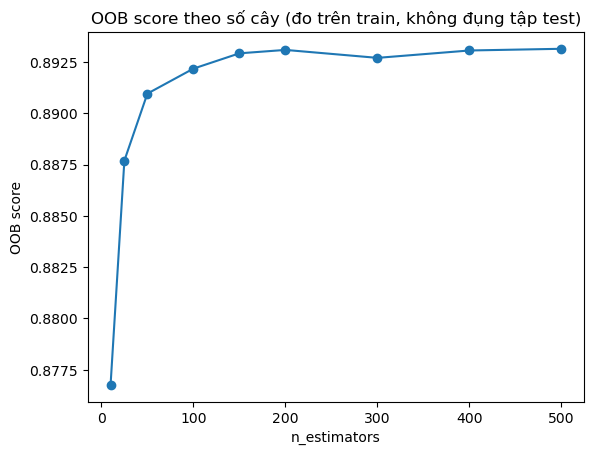

n_estimators tốt nhất theo OOB: 500


In [9]:
n_range = [10, 25, 50, 100, 150, 200, 300, 400, 500]
oob_scores = []

X_train_prep = clone(preprocess).fit_transform(X_train, y_train)

for n in n_range:
    m = RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                class_weight="balanced_subsample",
                                oob_score=True, n_jobs=-1, random_state=RANDOM_STATE)
    m.fit(X_train_prep, y_train)
    oob_scores.append(m.oob_score_)

plt.plot(n_range, oob_scores, marker="o")
plt.xlabel("n_estimators"); plt.ylabel("OOB score")
plt.title("OOB score theo số cây (đo trên train, không đụng tập test)")
plt.savefig(f"{REPORTS_DIR}/oob_theo_so_cay.png", dpi=120, bbox_inches="tight")
plt.show()

best_n = n_range[int(np.argmax(oob_scores))]
print("n_estimators tốt nhất theo OOB:", best_n)


## 8. Cross-validation + GridSearch cho mô hình chính

Trước đây không có bước CV hay GridSearch nào cho Random Forest. Thêm 5-fold `StratifiedKFold` trên `X_train` (tập test vẫn được giữ nguyên, chưa đụng tới) để so sánh vài tổ hợp tham số bằng ROC-AUC trung bình qua các fold.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(rf, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(f"CV ROC-AUC (n_estimators=400 mặc định): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

param_grid = {
    "clf__n_estimators": sorted(set([200, 400, best_n])),
    "clf__max_depth": [None, 10, 20],
}
grid = GridSearchCV(rf, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params (CV):", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.3f}")

# Mô hình cuối cùng = pipeline tốt nhất từ GridSearch, huấn luyện lại trên toàn bộ train.
rf = grid.best_estimator_
if hasattr(rf.named_steps["clf"], "oob_score_"):
    oob_score = rf.named_steps["clf"].oob_score_


CV ROC-AUC (n_estimators=400 mặc định): 0.780 ± 0.004
Best params (CV): {'clf__max_depth': 10, 'clf__n_estimators': 200}
Best CV ROC-AUC: 0.786


## 9. Đánh giá cuối cùng trên tập test

Đây là lần **duy nhất** tập test được dùng để tính điểm — sau khi mọi lựa chọn tham số đã chốt xong bằng OOB/CV ở trên.

In [11]:
auc_rf_test = eval_model(rf, "Random Forest (final)")


Random Forest (final) ROC-AUC = 0.794


## 10. Feature importance: mặc định (Gini) vs Permutation

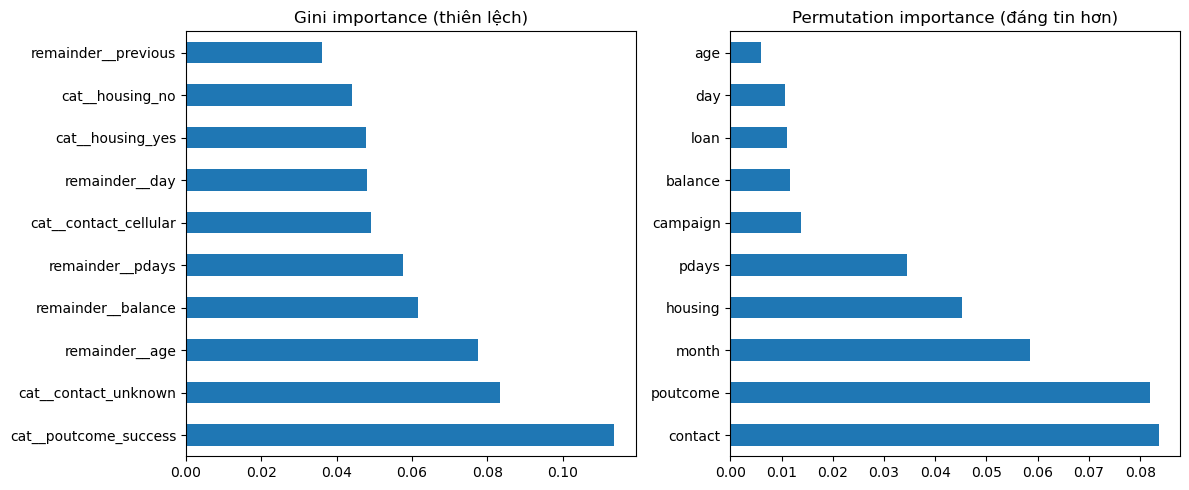

In [12]:
feat_names = rf.named_steps["prep"].get_feature_names_out()
gini_importance = pd.Series(
    rf.named_steps["clf"].feature_importances_, index=feat_names
).sort_values(ascending=False)

perm = permutation_importance(rf, X_test, y_test, n_repeats=10,
                               scoring="average_precision", random_state=RANDOM_STATE)
perm_importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
gini_importance.head(10).plot.barh(ax=axes[0], title="Gini importance (thiên lệch)")
perm_importance.head(10).plot.barh(ax=axes[1], title="Permutation importance (đáng tin hơn)")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/permutation_importance.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Precision@5000 và Lift — sản phẩm chính cho telesales

In [13]:
def lift_at_k(y_true, y_proba, k):
    idx = np.argsort(y_proba)[-k:]
    y_true = np.asarray(y_true)
    precision_top = y_true[idx].mean()
    lift = precision_top / y_true.mean()
    return precision_top, lift

proba_test = rf.predict_proba(X_test)[:, 1]
k = min(5000, len(y_test))
precision_5000, lift_5000 = lift_at_k(y_test, proba_test, k=k)
print(f"Precision@{k}: {precision_5000:.3f}  |  Lift: {lift_5000:.2f}x so với gọi ngẫu nhiên")


Precision@5000: 0.182  |  Lift: 1.55x so với gọi ngẫu nhiên


## 12. Đường Lift / Cumulative gain

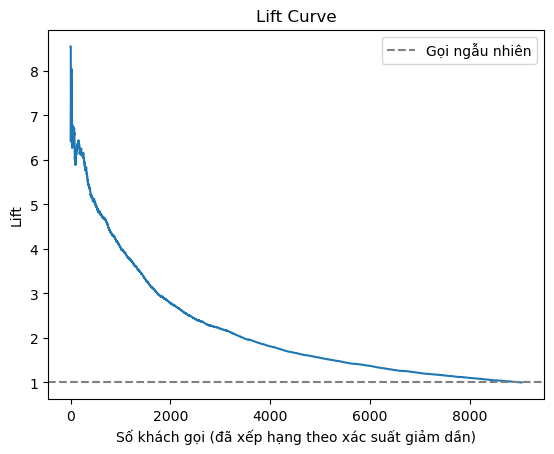

In [14]:
order = np.argsort(proba_test)[::-1]
y_sorted = np.asarray(y_test)[order]
cum_rate = np.cumsum(y_sorted) / np.arange(1, len(y_sorted) + 1)
lift_curve = cum_rate / y_test.mean()

plt.plot(lift_curve)
plt.axhline(1, color="gray", linestyle="--", label="Gọi ngẫu nhiên")
plt.xlabel("Số khách gọi (đã xếp hạng theo xác suất giảm dần)")
plt.ylabel("Lift")
plt.title("Lift Curve")
plt.legend()
plt.savefig(f"{REPORTS_DIR}/lift_curve.png", dpi=120, bbox_inches="tight")
plt.show()


## 13. Lưu toàn bộ metric ra file

Trước đây các số liệu (AUC, OOB, Precision@5000, Lift...) chỉ in ra màn hình và mất đi khi đóng notebook. Giờ ghi thành `reports/metrics.json` để có thể đối chiếu / so sánh giữa các lần chạy.

In [15]:
metrics = {
    "auc_dummy": float(auc_dummy),
    "auc_tree": float(auc_tree),
    "oob_score_rf": float(oob_score),
    "best_n_estimators_oob": int(best_n),
    "cv_auc_mean": float(cv_scores.mean()),
    "cv_auc_std": float(cv_scores.std()),
    "grid_best_params": grid.best_params_,
    "grid_best_cv_auc": float(grid.best_score_),
    "auc_rf_test": float(auc_rf_test),
    "precision_at_5000": float(precision_5000),
    "lift_at_5000": float(lift_5000),
}

with open(f"{REPORTS_DIR}/metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print(json.dumps(metrics, ensure_ascii=False, indent=2))


{
  "auc_dummy": 0.4970469796274442,
  "auc_tree": 0.7463547554310834,
  "oob_score_rf": 0.8223567794735678,
  "best_n_estimators_oob": 500,
  "cv_auc_mean": 0.7799135308345402,
  "cv_auc_std": 0.004405951539424627,
  "grid_best_params": {
    "clf__max_depth": 10,
    "clf__n_estimators": 200
  },
  "grid_best_cv_auc": 0.7863892956800471,
  "auc_rf_test": 0.7941178698717941,
  "precision_at_5000": 0.1816,
  "lift_at_5000": 1.5521822306238187
}


## 14. Xuất danh sách 5.000 khách ưu tiên gọi + lưu model

In [16]:
top5000_idx = np.argsort(proba_test)[-5000:][::-1]
danh_sach = X_test.iloc[top5000_idx].copy()
danh_sach["xac_suat_dong_y"] = proba_test[top5000_idx]
danh_sach.to_csv(f"{OUTPUTS_DIR}/danh_sach_goi_top5000.csv", index=False)

joblib.dump(rf, f"{MODELS_DIR}/rf_pipeline.joblib")
print(f"Đã lưu: {OUTPUTS_DIR}/danh_sach_goi_top5000.csv và {MODELS_DIR}/rf_pipeline.joblib")


Đã lưu: outputs/danh_sach_goi_top5000.csv và models/rf_pipeline.joblib
